# Gene Enrichment Analysis

Z-score 기반으로 선정된 질환별 마커 유전자에 대한 Gene Set Enrichment / Over-Representation Analysis.

| 입력 | 설명 |
|---|---|
| `Z_dis.npy` | disease Z-score matrix (n_dis × n_genes) |
| `GeneSelector` | gene_selectors.py의 selection methods |
| `gseapy.enrichr` | ORA — 유전자 리스트 기반 |
| `gseapy.prerank` | GSEA — Z-score ranking 기반 |


In [1]:
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '.')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import issparse
import scanpy as sc

from gene_selectors import GeneSelector
import sys, os 
parent_dir = str(Path(os.getcwd()).parent)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
from viz_style import apply_style
apply_style()

try:
    import gseapy as gp
    GSEAPY_OK = True
    print(f'gseapy {gp.__version__}')
except ImportError:
    GSEAPY_OK = False
    print('gseapy not installed — run: pip install gseapy')

BASE_DIR    = Path('.').resolve()
RESULTS_DIR = BASE_DIR / 'CV_Results'
FIG_DIR     = RESULTS_DIR / 'Figures' / 'GE'
FIG_DIR.mkdir(parents=True, exist_ok=True)

BIAS_COLUMNS = [
    'log(Total Reads)', 'Spliced Reads (%)',
    'gDNA Contamination (Intron/Exon)', 'rRNA Fraction',
    "RNA Degradation (3' Bias)", 'Platelet Score',
    'GC Bias', 'Gene Length Bias', 'NG80', '(NP80/NG80)',
]


gseapy 1.1.12


In [2]:
from sample_filter import MahalanobisFilter

# ── Z matrix + metadata 로드 ─────────────────────────────────────
Z_dis      = np.load(RESULTS_DIR / 'Z_disease.npy')
dis_names  = np.load(RESULTS_DIR / 'Z_sample_names.npy', allow_pickle=True).tolist()
gene_names = np.load(RESULTS_DIR / 'Z_gene_names.npy',   allow_pickle=True).tolist()

n_nan = np.isnan(Z_dis).sum() + np.isinf(Z_dis).sum()
Z_dis = np.nan_to_num(Z_dis.astype(np.float32), nan=0.0, posinf=10.0, neginf=-10.0)
print(f'Z_dis: {Z_dis.shape}  cleaned {n_nan:,} NaN/Inf')

adata    = sc.read_h5ad(BASE_DIR.parent / 'OpenAccess_nfcore' /
                        'Merged_Processed_AnnData_with_Batch_Biases_QC_Status.h5ad')
obs_mask = (
    (adata.obs['QC_Passed'] == True) &
    (adata.obs['Phenotype_Processed'].notna()) &
    (adata.obs['Phenotype_Processed'] != 'Unknown') &
    (adata.obs['broad_protocol_category'] != 'Exome-based (EB)')
)
adata     = adata[obs_mask, adata.var['GeneType'] == 'protein_coding'].copy()
is_hc     = (adata.obs['Phenotype_Processed'].astype(str) == 'Healthy Control').values
phenos    = adata.obs['Phenotype_Processed'].astype(str).values
dis_pheno = phenos[~is_hc]
X_raw     = adata.obs[BIAS_COLUMNS].values.astype(np.float64)

# ── OOD filtering (gene_selection.ipynb와 동일 기준) ─────────────
FILTER_PCT = 95
ood_filter = MahalanobisFilter(percentile=FILTER_PCT)
ood_filter.fit(X_raw[is_hc])

keep      = ood_filter.mask(X_raw[~is_hc])
Z_dis     = Z_dis[keep]
dis_pheno = dis_pheno[keep]

ood_filter.print_summary(X_raw[~is_hc], phenos[~is_hc])
print(pd.Series(dis_pheno).value_counts().to_string())


Z_dis: (913, 20097)  cleaned 510,367 NaN/Inf
Mahalanobis filter  P50=2.72  P95=5.19  P99=6.28
Threshold (P95=5.19):  retained 862 / 913  removed 51 (5.6%)
CDCS                  212
Tuberculosis          101
ME/CFS                 90
Pancreatitis           79
Pancreatic Cancer      72
Pre-eclampsia          59
Liver Cancer           40
Colorectal Cancer      37
Lung Cancer            30
Esophagus Cancer       25
Stomach Cancer         24
MM                     17
Other Cancer           16
HIV                    13
HIV + Tuberculosis     11
ICI-m                  11
ICI-treated Cancer     11
MGUS                    8
Liver Cirrhosis         4
Pancreatic Cancer       2


In [3]:
from gene_selectors import GeneSelector

id2sym = adata.var['GeneName']   # pd.Series(index=ENSG, values=symbol)
gs = GeneSelector(Z_dis, dis_pheno, gene_names)
gs.set_id2sym(id2sym)          

METHOD      = 'svd'   # 'proportion' | 'effect_size' | 'svd'
N_PER_PHENO = 200

genes_by_pheno = gs.top_ranked_per_pheno(n_per_pheno=N_PER_PHENO, method=METHOD)

print(f'Method: {METHOD}  n_per_pheno={N_PER_PHENO}')
for ph, gl in genes_by_pheno.items():
    print(f'  {ph:25s}: {len(gl)} genes  e.g. {gl[:4]}')


Method: svd  n_per_pheno=200
  CDCS                     : 200 genes  e.g. ['ST13', 'MT-ND5', 'MT-CO3', 'DAZAP2']
  Colorectal Cancer        : 200 genes  e.g. ['RPL37A', 'NDUFB3', 'IGF2', 'PET100']
  Esophagus Cancer         : 200 genes  e.g. ['UBL5', 'IGF2', 'CYREN', 'ACYP2']
  HIV                      : 200 genes  e.g. ['IFI27', 'IFI6', 'EIF2AK2', 'OAS1']
  HIV + Tuberculosis       : 200 genes  e.g. ['S100A8', 'SERPING1', 'GPI', 'AFF3']
  ICI-m                    : 200 genes  e.g. ['CYBA', 'PLBD1', 'APLP2', 'ATP6AP2']
  ICI-treated Cancer       : 200 genes  e.g. ['ZBED3', 'TMEM30A', 'CYBA', 'TGOLN2']
  Liver Cancer             : 200 genes  e.g. ['FGB', 'HRG', 'ALB', 'APOH']
  Liver Cirrhosis          : 200 genes  e.g. ['FAM83A', 'CREG1', 'C12orf76', 'ACER2']
  Lung Cancer              : 200 genes  e.g. ['SMIM27', 'WASHC3', 'COX7A2', 'HERPUD2']
  ME/CFS                   : 200 genes  e.g. ['CARD19', 'YPEL5', 'RPA1', 'VDAC3']
  MGUS                     : 200 genes  e.g. ['YIPF6', 'ENSG0

## ORA — Over-Representation Analysis (enrichr)

In [25]:
# ── Enrichr ORA: 질환별 마커 유전자 → 경로 enrichment ────────────
GENE_SETS = [
    'GO_Biological_Process_2023',
    'KEGG_2021_Human',
    'Reactome_2022',
]
FDR_THR = 0.05

if not GSEAPY_OK:
    print("gseapy가 설치되어 있지 않습니다. pip install gseapy 후 재실행.")
else:
    ora_results = {}
    for ph, gene_list in genes_by_pheno.items():
        if len(gene_list) < 5:
            continue
        try:
            enr = gp.enrichr(
                gene_list   = gene_list,
                gene_sets   = GENE_SETS,
                organism    = 'human',
                outdir      = None,
                cutoff      = FDR_THR,
            )
            df = enr.results
            df = df[df['Adjusted P-value'] < FDR_THR].copy()
            ora_results[ph] = df
            print(f'{ph:25s}: {len(df):4d} significant terms')
        except Exception as e:
            print(f'{ph}: ERROR — {e}')

    print(f'\nDone. {len(ora_results)} phenotypes with enrichment results.')


CDCS                     :  288 significant terms
Colorectal Cancer        :  332 significant terms
Esophagus Cancer         :   55 significant terms
HIV                      :  106 significant terms
HIV + Tuberculosis       :  206 significant terms
ICI-m                    :  143 significant terms
ICI-treated Cancer       :   95 significant terms
Liver Cancer             :  133 significant terms
Liver Cirrhosis          :   11 significant terms
Lung Cancer              :  364 significant terms
ME/CFS                   :    8 significant terms
MGUS                     :    4 significant terms
MM                       :   28 significant terms
Other Cancer             :   54 significant terms
Pancreatic Cancer        :   40 significant terms
Pancreatic Cancer        :   88 significant terms
Pancreatitis             :   67 significant terms
Pre-eclampsia            :    3 significant terms
Stomach Cancer           :  163 significant terms
Tuberculosis             :  121 significant terms


In [28]:
for key, report in ora_results.items():
    key = key.replace("/","_")
    report.to_csv(f"./CV_Results/GE/ora_result_{key}.csv", index=False)

## GSEA Prerank — Z-score 기반 ranking

In [ ]:
GSEA_GENE_SETS = ['KEGG_2021_Human', 'GO_Biological_Process_2023']
PHENOTYPE_TARGET = list(genes_by_pheno.keys())[0]  # 예시: 첫 번째 질환
if not GSEAPY_OK:
    print("gseapy 필요")
else:
    ranking = gs.mean_z_ranking(PHENOTYPE_TARGET)
    rnk_df  = pd.DataFrame(list(ranking.items()), columns=['gene', 'score'])
    rnk_df  = rnk_df.sort_values('score', ascending=False).reset_index(drop=True)
    print(f'Phenotype: {PHENOTYPE_TARGET}')
    print(f'Ranking range: [{rnk_df.score.min():.2f}, {rnk_df.score.max():.2f}]')
    display(rnk_df.head(10))
    gsea_res = gp.prerank(
        rnk         = rnk_df,
        gene_sets   = GSEA_GENE_SETS,
        outdir      = None,
        min_size    = 10,
        max_size    = 500,
        permutation_num = 100,
        seed        = 42,
        verbose     = False,
    )
    gsea_df = gsea_res.res2d[gsea_res.res2d['FDR q-val'] < FDR_THR].copy()
    print(f'\nSignificant GSEA terms: {len(gsea_df)}')
    display(gsea_df.sort_values('NES', ascending=False).head(20)[
        ['Term', 'NES', 'NOM p-val', 'FDR q-val', 'Tag %', 'Gene %']
    ])


Phenotype: CDCS
Ranking range: [-2.84, 2.62]


,gene,score
0,MT-ND5,2.619117
1,MT-CO3,2.448220
2,MT-CO1,2.247030
3,MT-ND4,2.202675
4,MT-CO2,2.155546
5,MT-ND1,2.115396
6,MT-ATP6,2.080543
7,MT-CYB,2.018117
8,MT-ND2,1.838523
9,MT-ND3,1.780960


2026-06-23 19:40:30,339 [WARNING] Duplicated values found in preranked stats: 2.80% of genes
The order of those genes will be arbitrary, which may produce unexpected results.



Significant GSEA terms: 119


,Term,NES,NOM p-val,FDR q-val,Tag %,Gene %
0,GO_Biological_Process_2023__Import Into Cell (...,2.588369,0.0,0.0,11/38,6.02%
1,KEGG_2021_Human__Nicotine addiction,2.426173,0.0,0.011742,20/40,17.34%
2,GO_Biological_Process_2023__Positive Regulatio...,2.28207,0.0,0.007828,7/13,14.60%
3,GO_Biological_Process_2023__Aminoglycan Biosyn...,2.2308,0.0,0.011742,10/21,12.41%
4,GO_Biological_Process_2023__Regulation Of Sens...,2.14845,0.0,0.018787,3/12,7.67%
6,GO_Biological_Process_2023__Regulation Of Sens...,2.092261,0.0,0.043053,3/14,7.67%
160,GO_Biological_Process_2023__Regulation Of Andr...,-1.571037,0.0,0.049976,18/27,24.17%
154,KEGG_2021_Human__Nucleotide excision repair,-1.574415,0.0,0.049888,29/46,19.65%
153,KEGG_2021_Human__RNA transport,-1.574902,0.0,0.049751,91/165,22.53%
146,GO_Biological_Process_2023__Negative Regulatio...,-1.579793,0.0,0.048619,28/39,22.82%


## ORA 결과 요약 시각화

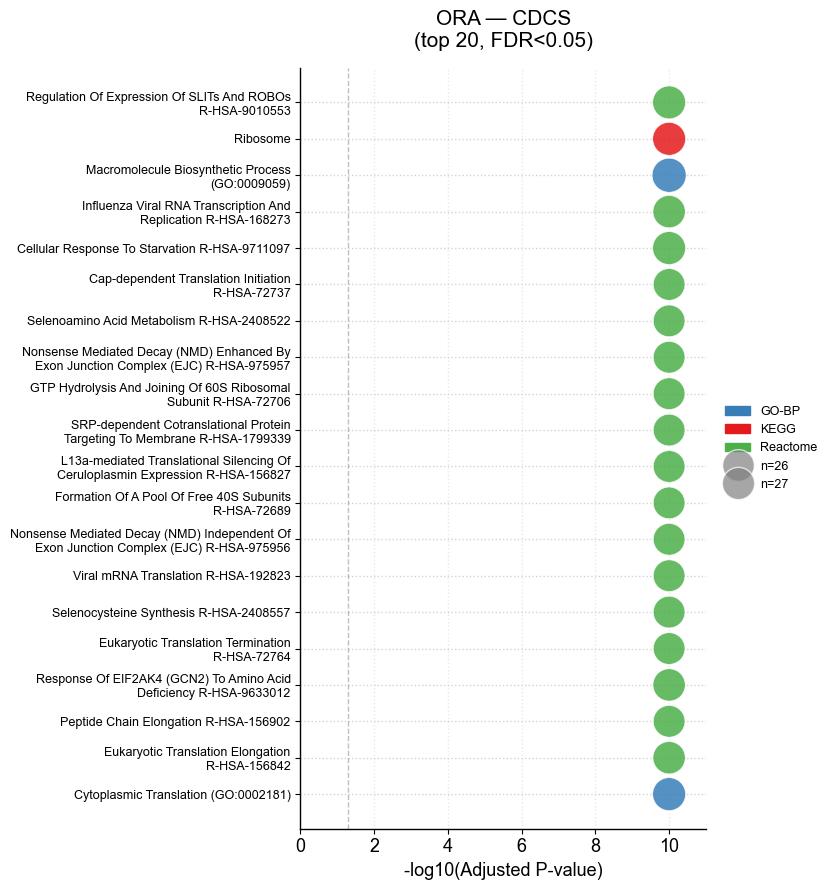

CDCS: 20 terms


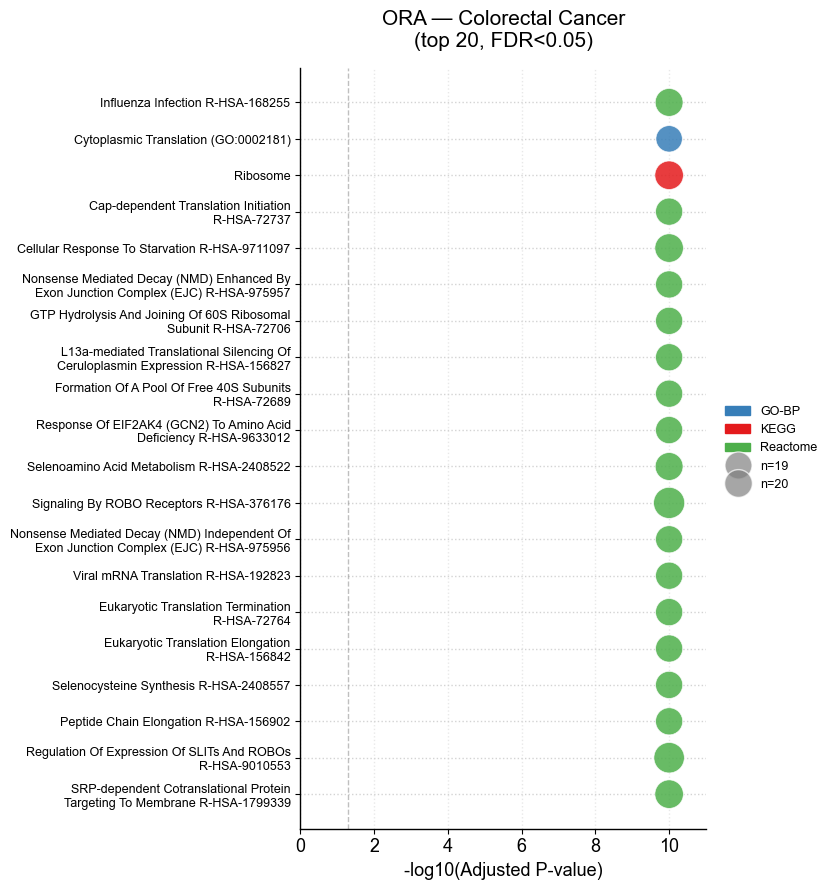

Colorectal Cancer: 20 terms


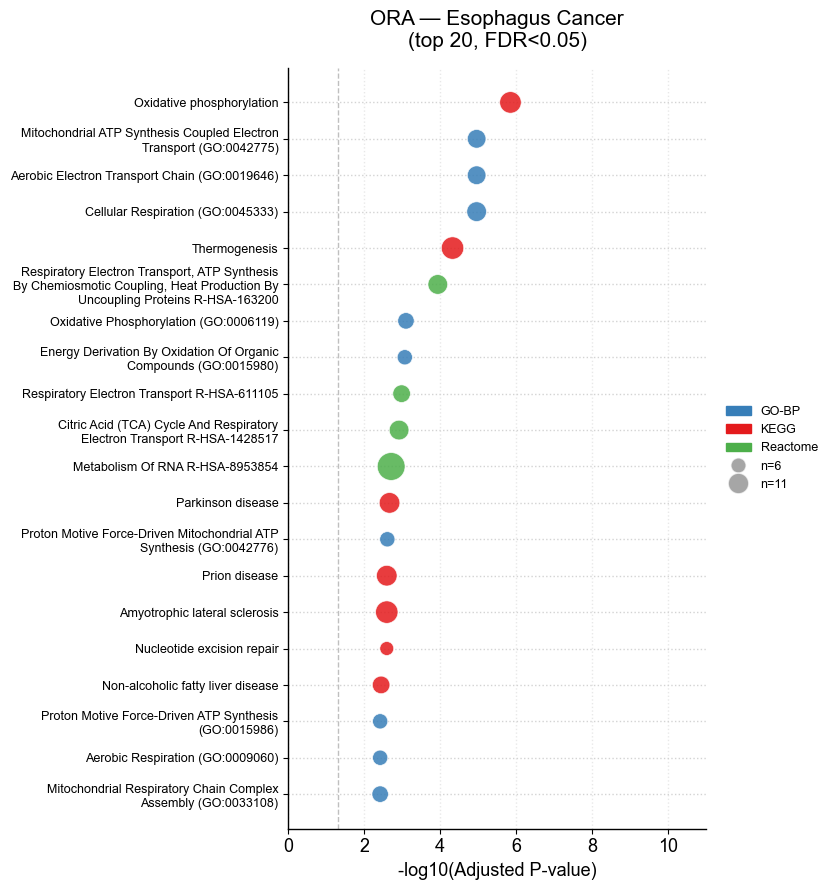

Esophagus Cancer: 20 terms


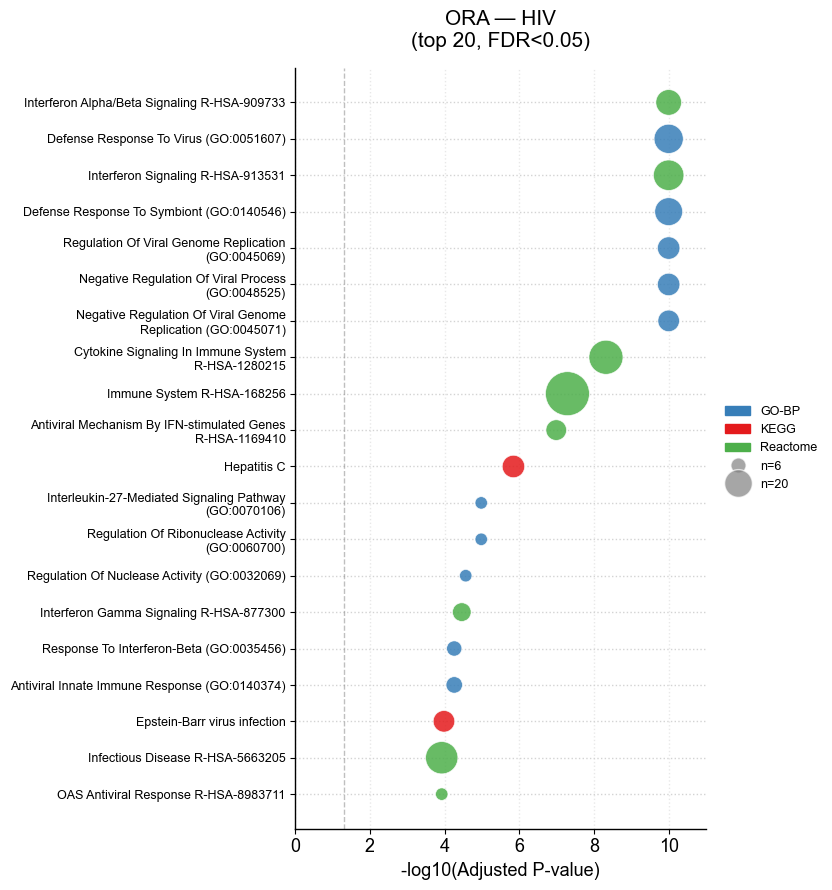

HIV: 20 terms


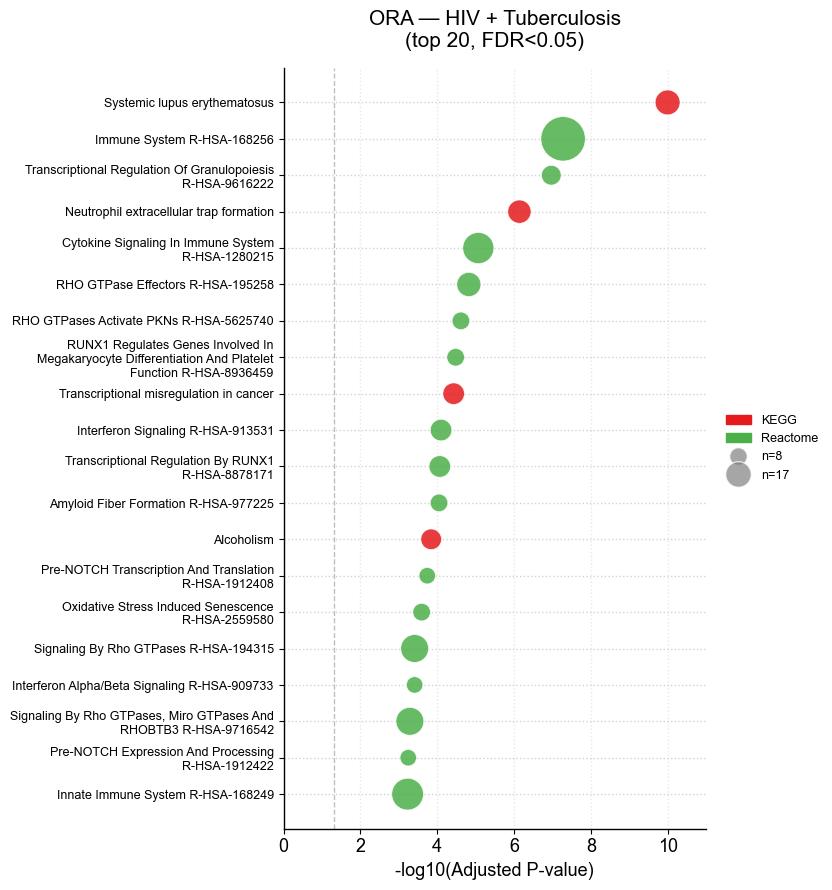

HIV + Tuberculosis: 20 terms


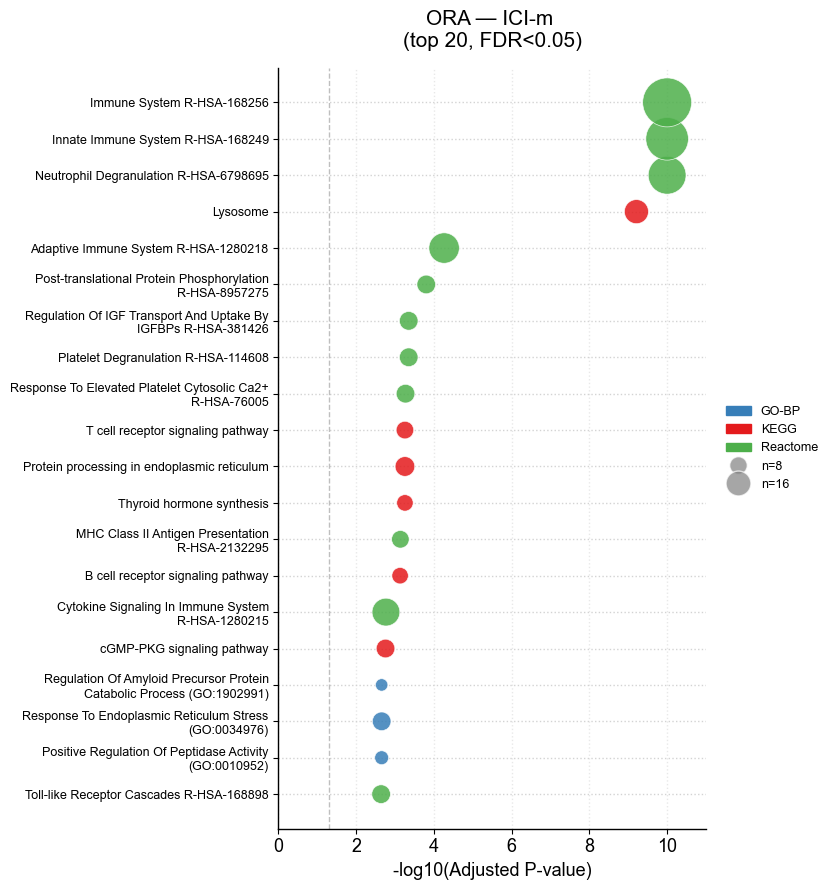

ICI-m : 20 terms


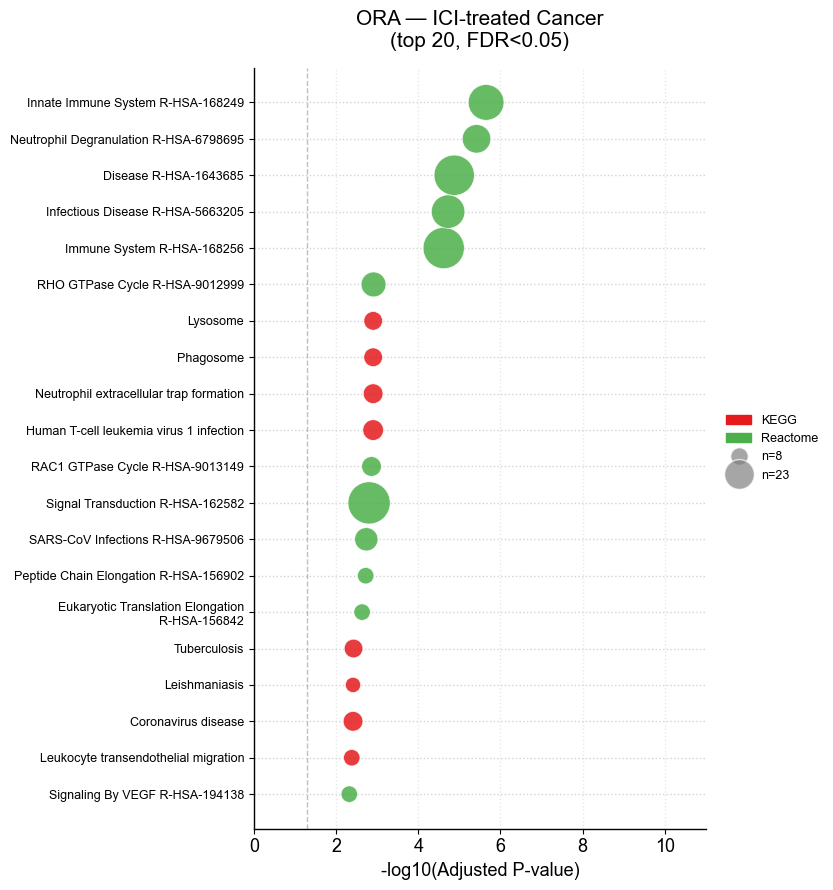

ICI-treated Cancer: 20 terms


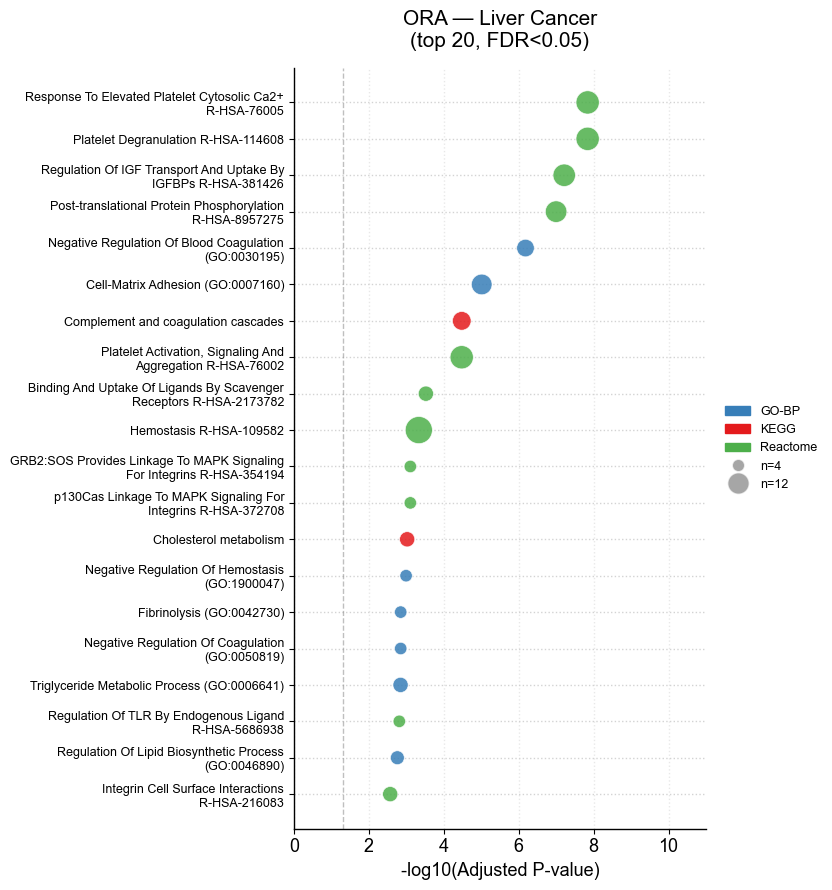

Liver Cancer: 20 terms


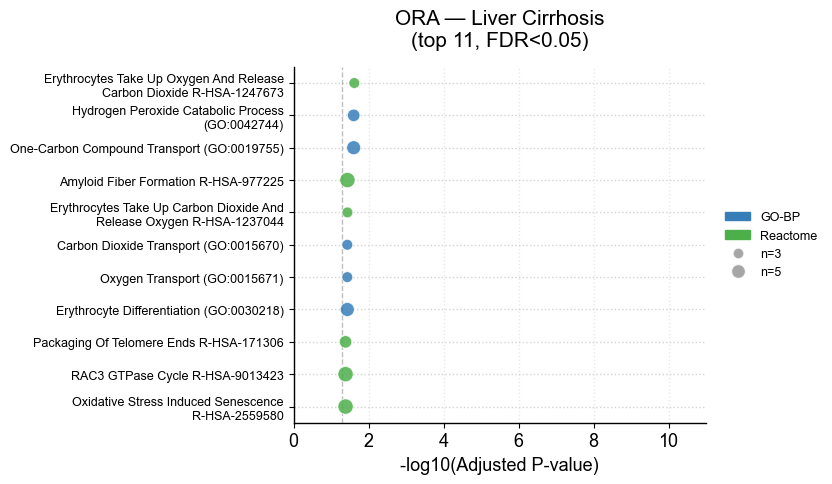

Liver Cirrhosis: 11 terms


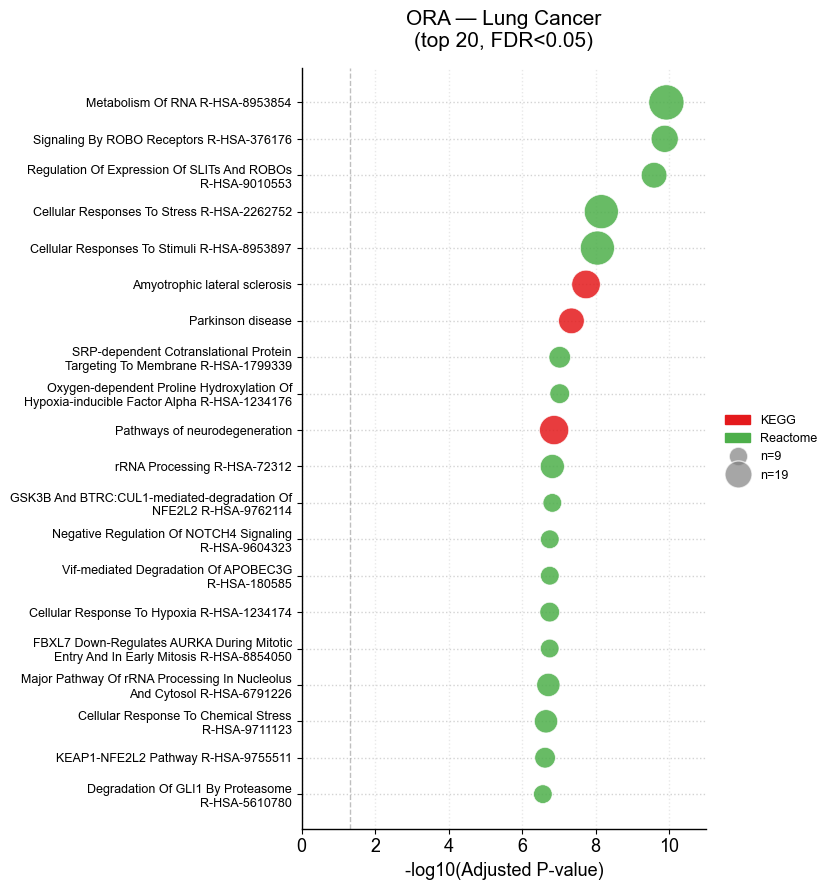

Lung Cancer: 20 terms


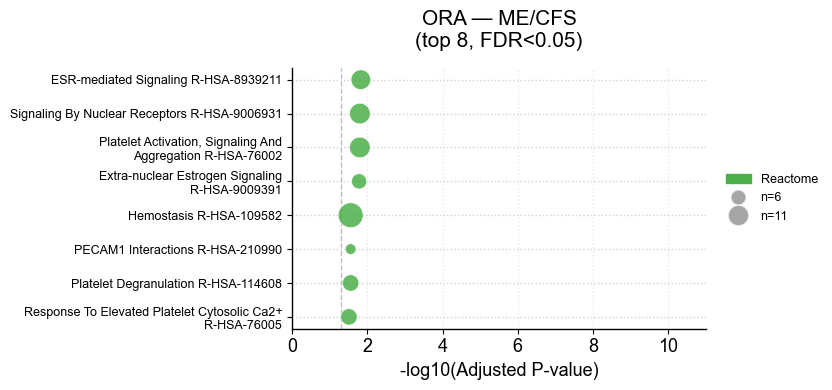

ME/CFS: 8 terms


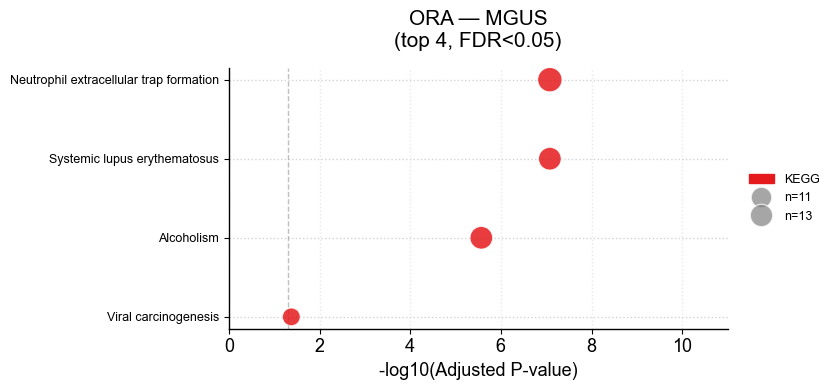

MGUS: 4 terms


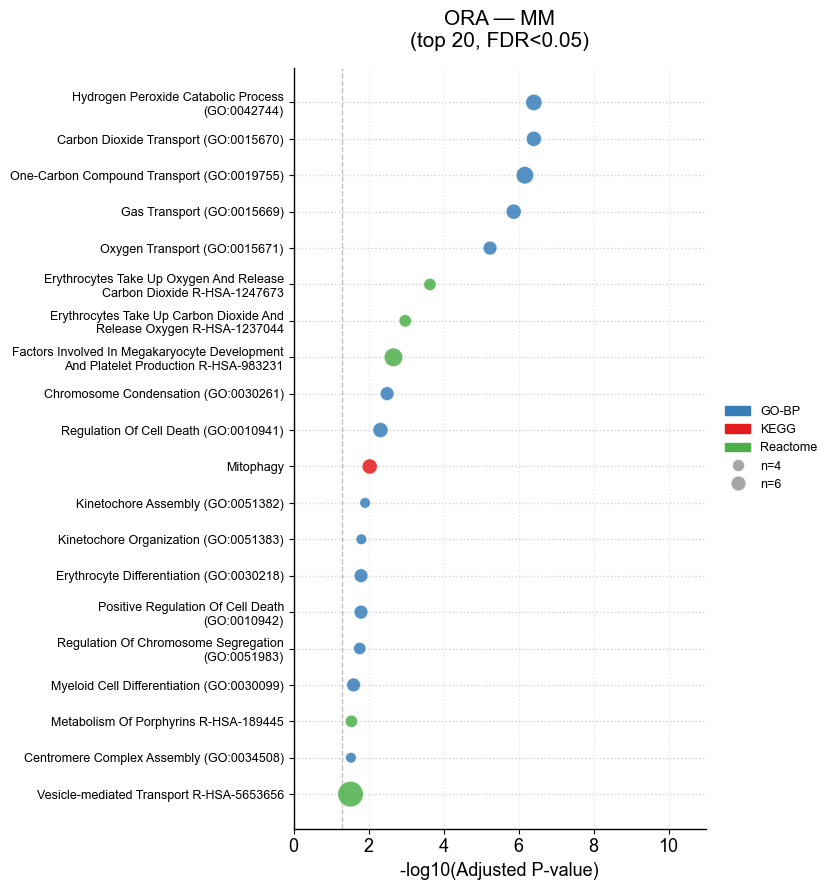

MM: 20 terms


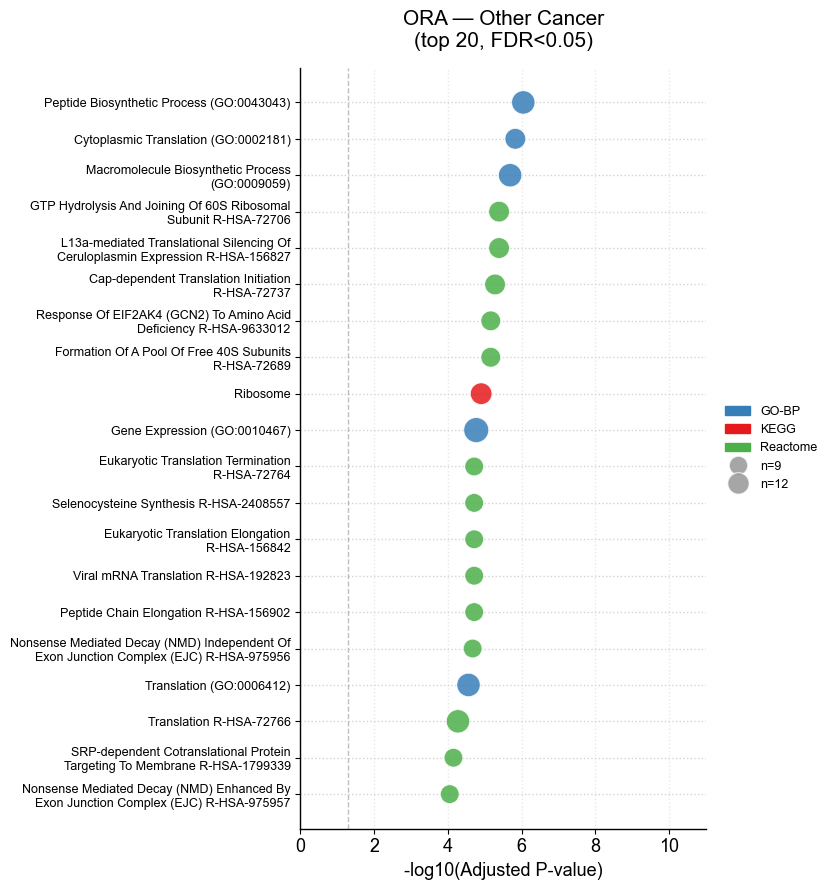

Other Cancer: 20 terms


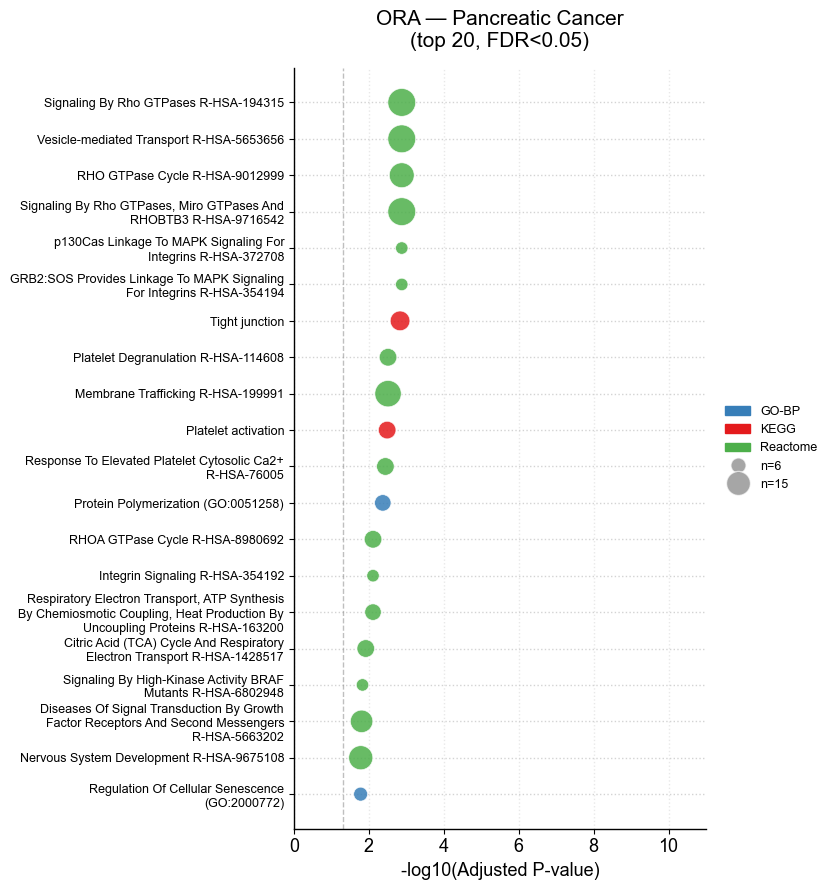

Pancreatic Cancer: 20 terms


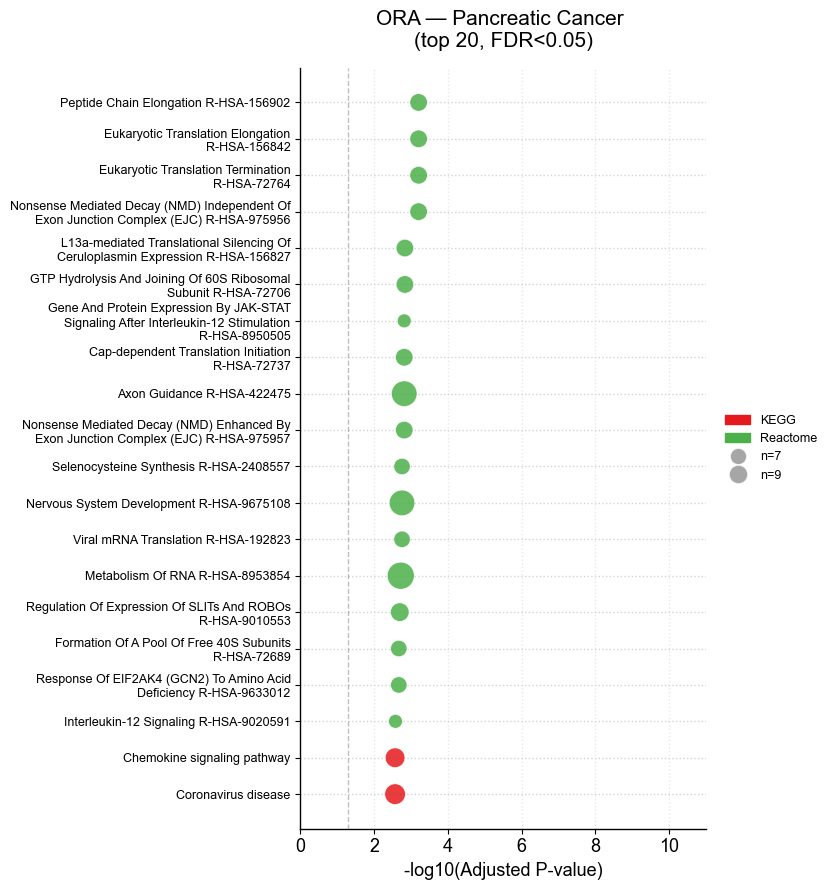

Pancreatic Cancer : 20 terms


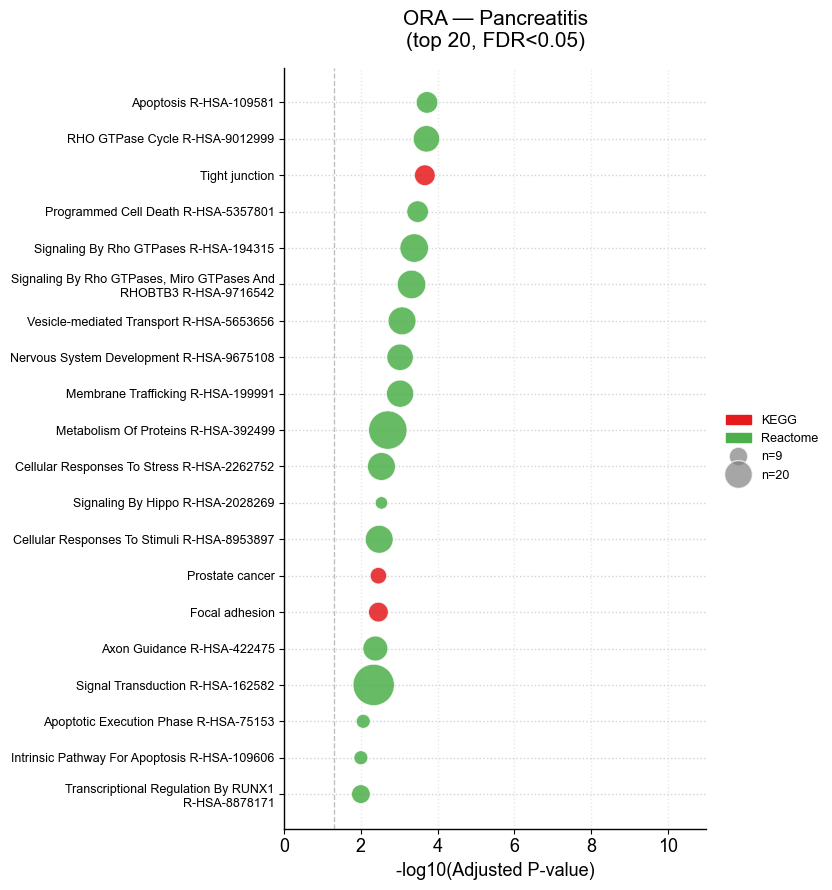

Pancreatitis: 20 terms


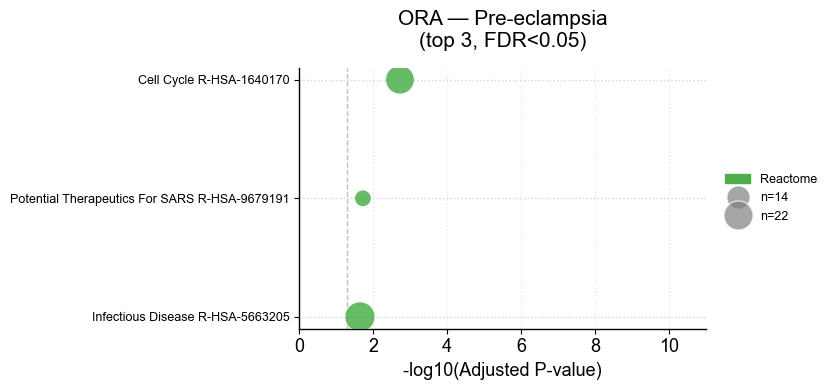

Pre-eclampsia: 3 terms


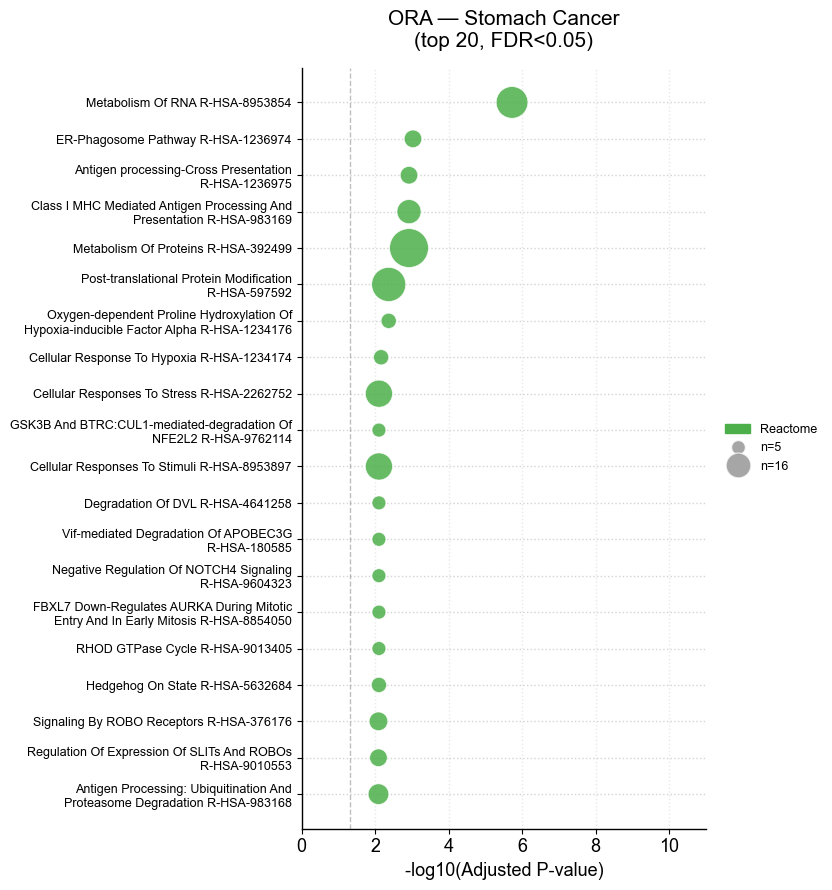

Stomach Cancer: 20 terms


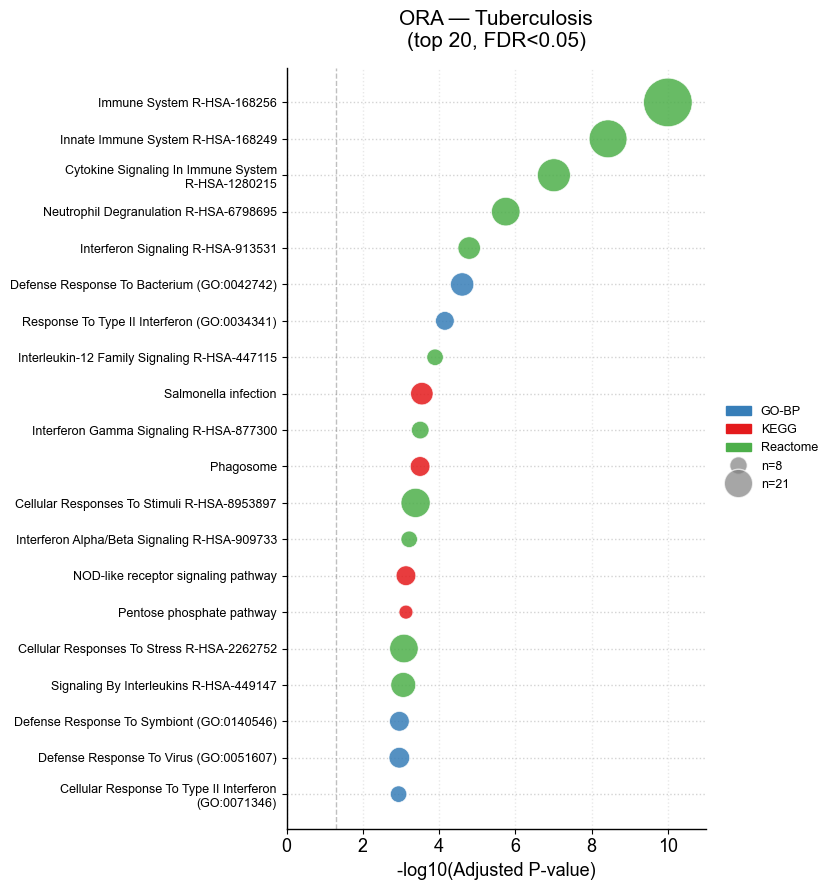

Tuberculosis: 20 terms


In [9]:
import textwrap

# ── 질환별 ORA 결과 개별 dot-plot ────────────────────────────────
if not GSEAPY_OK or not ora_results:
    print("ORA 결과 없음")
else:
    TOP_N   = 20
    DB_COLORS = {
        'GO_Biological_Process_2023': '#377EB8',
        'KEGG_2021_Human':            '#E41A1C',
        'Reactome_2022':              '#4DAF4A',
    }
    DB_LABELS = {
        'GO_Biological_Process_2023': 'GO-BP',
        'KEGG_2021_Human':            'KEGG',
        'Reactome_2022':              'Reactome',
    }

    for ph, df in ora_results.items():
        if df.empty:
            print(f'{ph}: 유의한 term 없음 (FDR<{FDR_THR})')
            continue

        plot_df = (df.nsmallest(TOP_N, 'Adjusted P-value')
                   .copy().reset_index(drop=True))
        plot_df['neg_log_fdr'] = -np.log10(plot_df['Adjusted P-value'].clip(1e-10))
        plot_df['overlap_n']   = plot_df['Overlap'].str.split('/').str[0].astype(int)
        plot_df['color']       = plot_df['Gene_set'].map(DB_COLORS).fillna('#888888')
        plot_df['db_label']    = plot_df['Gene_set'].map(DB_LABELS).fillna('Other')
        
        # 긴 Term 이름을 45자 기준으로 줄바꿈(wrap) 처리하여 Y축 잘림 방지
        plot_df['Term_wrap'] = plot_df['Term'].apply(
            lambda x: textwrap.fill(x, width=45, break_long_words=False)
        )
        
        plot_df = plot_df.sort_values('neg_log_fdr', ascending=True)

        fig, ax = plt.subplots(figsize=(10, max(4, len(plot_df) * 0.45)))
        
        ax.grid(True, axis='y', linestyle=':', color='lightgrey', zorder=0)
        ax.grid(True, axis='x', linestyle=':', color='lightgrey', alpha=0.5, zorder=0)
        ax.scatter(
            plot_df['neg_log_fdr'],
            range(len(plot_df)),
            s          = plot_df['overlap_n'] * 20,
            c          = plot_df['color'],
            alpha      = 0.85,
            edgecolors = 'white',
            linewidths = 0.5,
            zorder     = 3,
        )
        ax.axvline(-np.log10(FDR_THR), color='grey', lw=1, ls='--', alpha=0.5)
        ax.set_xlim(0, 11)
        ax.set_yticks(range(len(plot_df)))
        ax.set_yticklabels(plot_df['Term_wrap'], fontsize=9)
        ax.set_xlabel('-log10(Adjusted P-value)')
        ax.set_title(f'ORA — {ph}\n(top {len(plot_df)}, FDR<{FDR_THR})', pad=15)

        from matplotlib.patches import Patch
        from matplotlib.lines import Line2D
        
        db_present = plot_df['Gene_set'].unique()
        db_patches = [Patch(color=DB_COLORS[db], label=DB_LABELS[db])
                      for db in DB_COLORS if db in db_present]
        
        size_quantiles = plot_df['overlap_n'].quantile([0.25, 0.75]).astype(int).unique().tolist()
        size_ex    = [Line2D([0],[0], marker='o', color='w',
                             markerfacecolor='grey', alpha=0.7,
                             markersize=np.sqrt(n*20), label=f'n={n}')
                      for n in sorted(size_quantiles)]
        
        ax.legend(handles=db_patches + size_ex,
                  frameon=False, fontsize=9, 
                  loc='center left', bbox_to_anchor=(1.02, 0.5))

        plt.tight_layout(rect=[0, 0, 0.85, 1]) 
        
        fname = ph.replace(' ', '_').replace('/', '_')
        plt.savefig(FIG_DIR / f'ora_{fname}.png', bbox_inches='tight', dpi=150)
        plt.show()
        print(f'{ph}: {len(plot_df)} terms')